# Vizual ko'rinishlar

In [57]:
import pandas as pd

In [58]:
# preprocessed papkadan tayyor datasetni import qilib olish 
df = pd.read_csv("preprocessed\imdb_top_1000.csv")

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Released_Year  1000 non-null   int64  
 1   Certificate    1000 non-null   int64  
 2   Runtime        1000 non-null   int64  
 3   Genre          1000 non-null   int64  
 4   IMDB_Rating    1000 non-null   float64
 5   Meta_score     1000 non-null   float64
 6   Director       1000 non-null   int64  
 7   Star1          1000 non-null   int64  
 8   Star2          1000 non-null   int64  
 9   Star3          1000 non-null   int64  
 10  Star4          1000 non-null   int64  
 11  No_of_Votes    1000 non-null   int64  
 12  Gross          1000 non-null   float64
dtypes: float64(3), int64(10)
memory usage: 101.7 KB


# Algorithms

In [60]:
import pandas as pd
import xgboost as xgb
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df.select_dtypes(include=['int64', 'float64']).drop(['Sale_ID'], axis=1, errors='ignore')
y = df['IMDB_Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVM (SVR)": SVR(kernel='rbf'),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    score = model.score(X_test, y_test)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    
    results.append([name, f"{score:.4f}", f"{mae:.4f}", f"{mse:.4f}"])

headers = ["Model", "R2 Score", "MAE", "MSE"]
print(tabulate(results, headers=headers, tablefmt="grid"))

+-------------------+------------+--------+--------+
| Model             |   R2 Score |    MAE |    MSE |
+===================+============+========+========+
| Linear Regression |     1      | 0      | 0      |
+-------------------+------------+--------+--------+
| Decision Tree     |     1      | 0      | 0      |
+-------------------+------------+--------+--------+
| Random Forest     |     1      | 0.0001 | 0      |
+-------------------+------------+--------+--------+
| SVM (SVR)         |    -0.0071 | 0.2064 | 0.0646 |
+-------------------+------------+--------+--------+
| XGBoost           |     1      | 0      | 0      |
+-------------------+------------+--------+--------+


# Model Visual Analysis (IMDB Rating Prediction)

In [61]:
# Kerakli kutubxonalarni import qilish
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Modellarni solishtirish (R2 Score)

<function matplotlib.pyplot.show(close=None, block=None)>

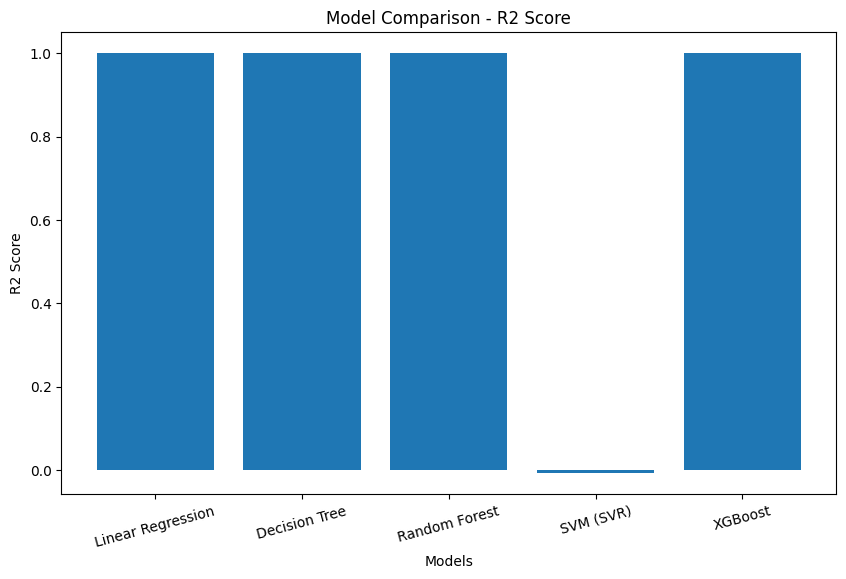

In [62]:
model_names = []
r2_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    
    model_names.append(name)
    r2_scores.append(score)

plt.figure(figsize=(10,6))
plt.bar(model_names, r2_scores)
plt.title("Model Comparison - R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=15)
plt.show

# MAE va MSE comparison

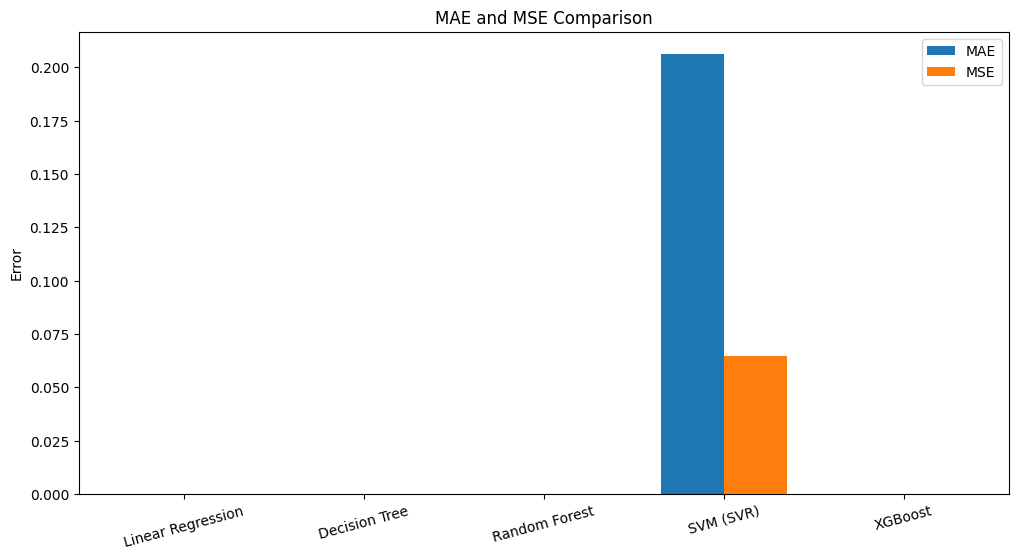

In [63]:
# Bu grafik errorlarni ko‘rsatadi
mae_scores = []
mse_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    mae_scores.append(mean_absolute_error(y_test, pred))
    mse_scores.append(mean_squared_error(y_test, pred))

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, mae_scores, width, label='MAE')
plt.bar(x + width/2, mse_scores, width, label='MSE')

plt.xticks(x, model_names, rotation=15)
plt.ylabel("Error")
plt.title("MAE and MSE Comparison")
plt.legend()
plt.show()

# Actual vs Predicted (Random Forest)

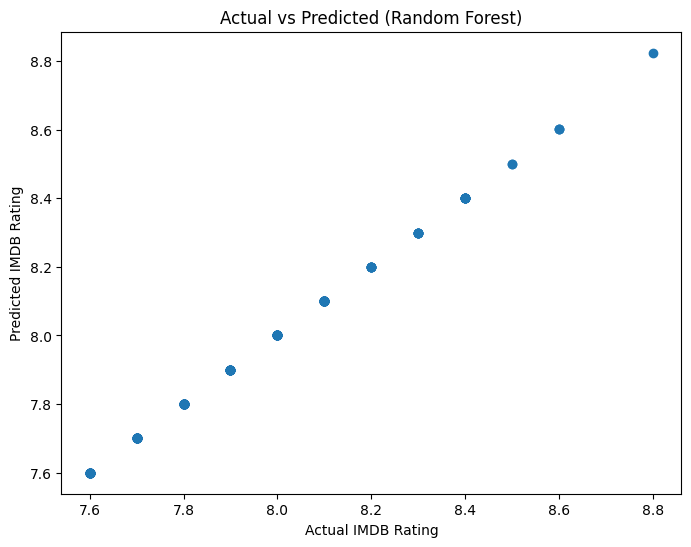

In [64]:
# Bu grafik model prediction qanchalik to‘g‘ri ekanligini ko‘rsatadi
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual IMDB Rating")
plt.ylabel("Predicted IMDB Rating")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

# Feature Importance (Random Forest)

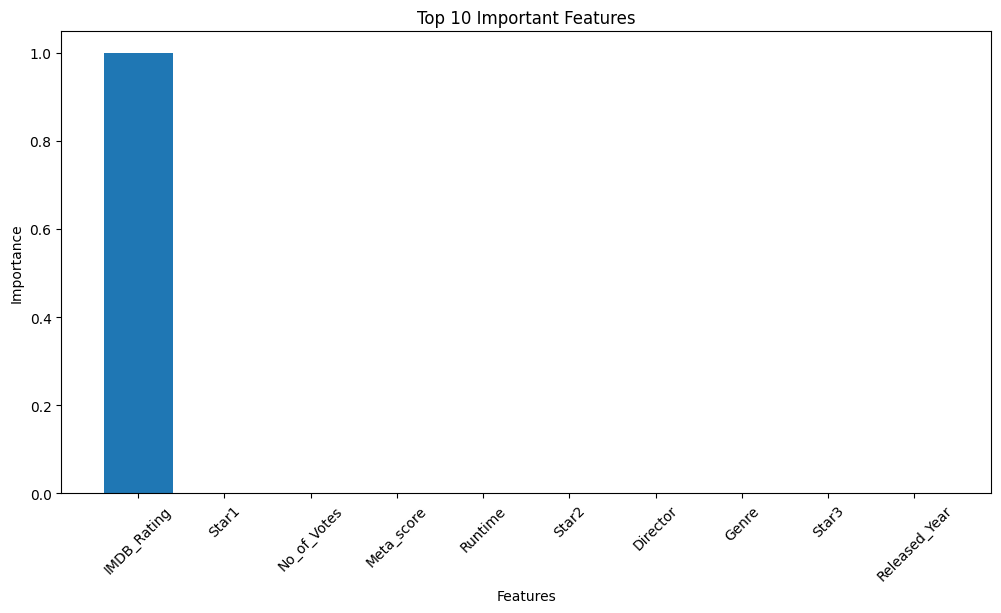

In [65]:
importance = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,6))
plt.bar(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# Correlation Heatmap

In [66]:
import pandas as pd
import plotly.express as px

# 1. Correlation matrix yaratish
corr_matrix = df.corr(numeric_only=True)

# 2. Heatmap chizish
fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    aspect="auto",
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
)

fig.update_layout(
    width=900,
    height=800,
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()

# XGBoost Prediction Analysis

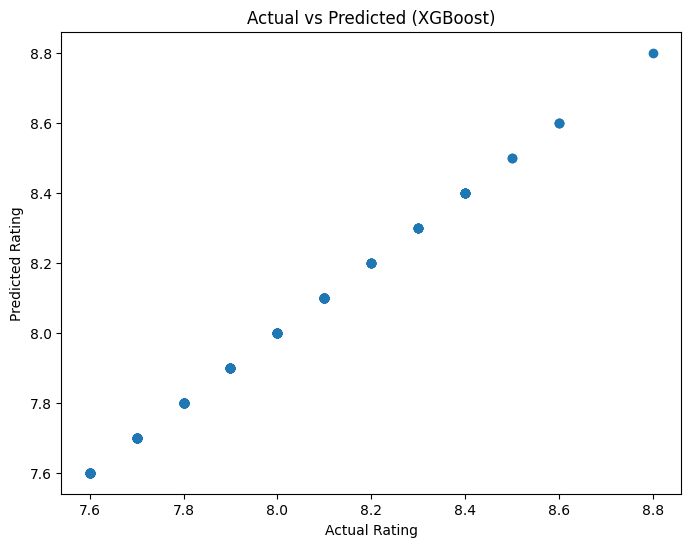

In [67]:
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_xgb)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()

# Residual Error Analysis

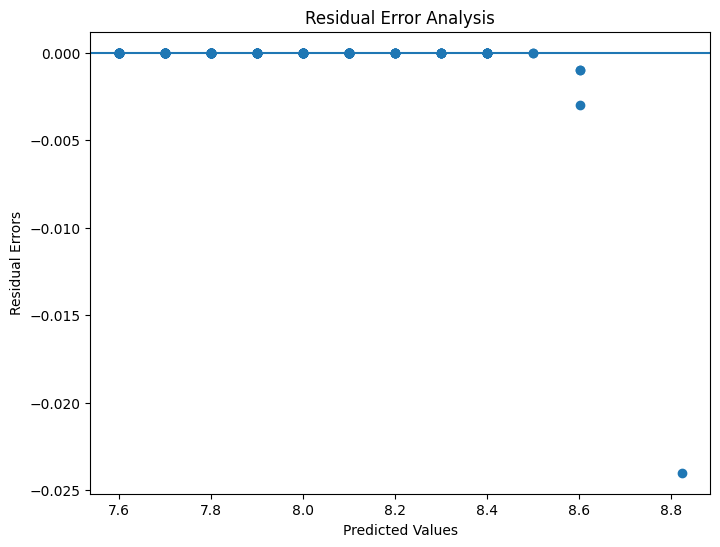

In [68]:
# Model qayerlarda xato qilayotganini ko‘rsatadi
residuals = y_test - pred_rf

plt.figure(figsize=(8,6))
plt.scatter(pred_rf, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")
plt.title("Residual Error Analysis")
plt.show()